# 1. Análise Exploratória (EDA): Características dos Change Points
Esta etapa valida as *features* extraídas dos eventos de rede antes da classificação pelo GMM.

## Parametrização e Contexto
A análise fundamenta-se na identificação de **transições de estado** na rede. Cada registro representa um ponto de mudança (*Change Point*) que delimita a fronteira estatística entre dois regimes operacionais distintos.

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Configurações de Aparência ---
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

# --- Parâmetros do Estudo ---
SCENARIO = "NDT"
METHOD = "vwcd"
REF_METRIC = "rtt_down"
THRESHOLD = 0.95

# --- Caminho do Arquivo de Features ---
base_path = os.path.join("features", SCENARIO)
if METHOD.startswith("vwcd"):
    file_name = f"features_{METHOD}_{REF_METRIC}_{THRESHOLD}.csv"
else:
    file_name = f"features_{METHOD}_{REF_METRIC}.csv"

full_path = os.path.join(base_path, file_name)

# --- Carregamento ---
df = pd.read_csv(full_path)
print(f"Dataset carregado com sucesso!")


abs_rel = 'rel'
df['d_rtt_up'] = df[f'd_rtt_up_{abs_rel}'] 
df['d_rtt_down'] = df[f'd_rtt_down_{abs_rel}']
relativa_absoluta = 'Relativa' if abs_rel == 'rel' else 'Absoluta'

corte = 10 # ms
outlier_cut = True

Dataset carregado com sucesso!


### Caracterização Geral do Dataset

Esta etapa quantifica o volume de dados e a diversidade de dispositivos no período analisado para garantir que a base suporta o uso do GMM.

In [2]:
def EDA(df_ana):

    # Extração da Janela Temporal
    df_ana['timestamp'] = pd.to_datetime(df_ana['timestamp'])
    data_inicio = df_ana['timestamp'].min().strftime('%m/%Y')
    data_fim = df_ana['timestamp'].max().strftime('%m/%Y')

    # Identificação das entidades únicas no dataset
    total_clients = df_ana['client'].nunique()
    total_servers = df_ana['server'].nunique()
    total_pairs = df_ana.groupby(['client', 'server']).ngroups
    total_events = len(df_ana)

    # Cálculo da densidade de eventos por conexão
    avg_cp_per_pair = total_events / total_pairs if total_pairs > 0 else 0

    # Exibição do Relatório de Viabilidade
    print(f"{'='*50}")
    print(f" RELATÓRIO DE CARACTERIZAÇÃO DO CENÁRIO: {SCENARIO}")
    print(f"{'='*50}")
    print(f"Período de Análise:                 {data_inicio} até {data_fim}")
    print(f"Limiar de Detecção:                 {THRESHOLD}")
    print(f"Total de Clientes únicos:           {total_clients}")
    print(f"Total de Servidores únicos:         {total_servers}")
    print(f"Total de Pares Cliente-Servidor:    {total_pairs}")
    print(f"Total de Eventos (Change Points):   {total_events}")
    print(f"Média de eventos por par:           {avg_cp_per_pair:.2f}")
    print(f"{'='*50}")

    # --- Análise de Sincronização e Distribuições de Variação (Deltas) ---

    # Seleção das métricas e configurações de plotagem
    metrics_to_plot = [
        ('d_rtt_down', f'Variação {relativa_absoluta} RTT Down', 'teal'),
        ('d_tp_down', f'Variação {relativa_absoluta} Throughput Down', 'darkred'),
        ('d_pl', 'Variação Relativa Packet Loss', 'indigo'),
        ('d_rtt_up', 'Variação Relativa RTT Up', 'darkcyan'),
        ('d_tp_up', 'Variação Relativa Throughput Up', 'firebrick')
    ]

    # Criação da figura 2x3 para consolidar todas as análises
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    plt.suptitle("Análise de Densidade e Sincronização das Características (Features)", fontsize=16)
    axes_flat = axes.flatten()

    # 1. Plotagem dos Histogramas com KDE para os Deltas (Primeiras 5 posições)
    for i, (col, label, color) in enumerate(metrics_to_plot):
        if col in df_ana.columns:
            sns.histplot(df_ana[col], kde=True, color=color, ax=axes_flat[i], bins=30)
            axes_flat[i].set_title(label)
            axes_flat[i].set_xlabel("Valor do $\\Delta$")
            axes_flat[i].set_ylabel("Frequência")

    # 2. Plotagem do Synchronization Score (S_e) na sexta posição
    ax_sync = axes_flat[5]
    sns.countplot(data=df_ana.assign(sync_score=(df_ana['sync_score'] * 5).astype(int)), x='sync_score', hue='sync_score', palette='viridis', ax=ax_sync, legend=False)

    ax_sync.set_title("Distribuição do Synchronization Score ($S_{e}$)")
    ax_sync.set_xlabel("Sync Score (Fração de métricas)")
    ax_sync.set_ylabel("Contagem de Eventos")

    # Adição de labels de porcentagem sobre as barras do Sync Score
    total = len(df_ana)
    for p in ax_sync.patches:
        height = p.get_height()
        if height > 0:
            percentage = f'{100 * height / total:.1f}%'
            ax_sync.annotate(percentage, (p.get_x() + p.get_width() / 2, height), 
                            ha='center', va='bottom', fontsize=10)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()



    # Configuração das métricas para a plotagem individual dos boxplots
    metrics_to_plot_box = [
        ('d_rtt_down', f'Variação {relativa_absoluta} RTT Down', 'teal'),
        ('d_rtt_up', f'Variação {relativa_absoluta} RTT Up', 'lightseagreen'),
        ('d_tp_down', 'Variação Relativa Throughput Down', 'darkred'),
        ('d_tp_up', 'Variação Relativa Throughput Up', 'indianred'),
        ('d_pl', 'Variação Relativa Packet Loss', 'indigo'),
        ('sync_score', 'Synchronization Score ($S_{e}$)', 'purple')
    ]

    # Geração de uma figura independente para cada métrica
    for col, label, color in metrics_to_plot_box:
        if col in df_ana.columns:
            plt.figure(figsize=(10, 3))
            
            # Criação do boxplot horizontal
            sns.boxplot(
                x=df_ana.assign(sync_score=(df_ana['sync_score'] * 5).astype(int))[col], 
                color=color, 
                width=0.4, 
                fliersize=5, 
                linewidth=1.5
            )
            
            plt.title(f"Dispersão e Outliers: {label}", fontsize=13)
            plt.xlabel("Valor do $\\Delta$")
            
            # Ajuste de layout para evitar cortes
            plt.tight_layout()
            plt.show()

    # --- Matriz de Correlação Global ---

    plt.figure(figsize=(10, 8))
    corr_cols = ['d_rtt_up', 'd_rtt_down', 'd_tp_up', 'd_tp_down', 'd_pl', 'sync_score']
    correlation_matrix = df_ana[corr_cols].corr()

    # Mapa de calor para identificar dependências multivariadas
    sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f", square=True)

    plt.title("Matriz de Correlação entre Features")
    plt.show()

    # --- Comparação de Assinaturas: Download vs Upload ---

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # 1. Download: RTT vs Throughput
    sns.scatterplot(data=df_ana.assign(sync_score=(df_ana['sync_score'] * 5).astype(int)), x='d_rtt_down', y='d_tp_down', 
                    hue='sync_score', palette='viridis', s=80, alpha=0.7, ax=axes[0])
    axes[0].axhline(0, color='black', lw=1, ls='--')
    axes[0].axvline(0, color='black', lw=1, ls='--')
    axes[0].set_title(r"Assinatura Download: $\Delta RTT_{down}$ vs $\Delta TP_{down}$")
    axes[0].set_xlabel(f"Variação RTT Down ({relativa_absoluta})")
    axes[0].set_ylabel("Variação TP Down (Relativa)")
    # axes[0].set_xlim(-50, 50)
    # axes[0].set_ylim(-1, 1)

    # 2. Upload: RTT vs Throughput
    sns.scatterplot(data=df_ana.assign(sync_score=(df_ana['sync_score'] * 5).astype(int)), x='d_rtt_up', y='d_tp_up', 
                    hue='sync_score', palette='viridis', s=80, alpha=0.7, ax=axes[1])
    axes[1].axhline(0, color='black', lw=1, ls='--')
    axes[1].axvline(0, color='black', lw=1, ls='--')
    axes[1].set_title(r"Assinatura Upload: $\Delta RTT_{up}$ vs $\Delta TP_{up}$")
    axes[1].set_xlabel(f"Variação RTT Up ({relativa_absoluta})")
    axes[1].set_ylabel("Variação TP Up (Relativa)")

    plt.tight_layout()
    plt.show()

    # --- Análise do Impacto da Perda de Pacotes ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # 1. Packet Loss vs RTT Down
    sns.scatterplot(data=df_ana.assign(sync_score=(df_ana['sync_score'] * 5).astype(int)), x='d_rtt_down', y='d_pl', 
                    hue='sync_score', palette='viridis', s=80, alpha=0.7, ax=axes[0])
    axes[0].axhline(0, color='black', lw=1, ls='--')
    axes[0].axvline(0, color='black', lw=1, ls='--')
    axes[0].set_title(r"Impacto na Latência: $\Delta RTT_{down}$ vs $\Delta PL$")
    axes[0].set_xlabel(f"Variação RTT Down ({relativa_absoluta})")
    axes[0].set_ylabel("Variação Perda de Pacotes")

    # 2. Packet Loss vs Throughput Down
    sns.scatterplot(data=df_ana.assign(sync_score=(df_ana['sync_score'] * 5).astype(int)), x='d_tp_down', y='d_pl', 
                    hue='sync_score', palette='viridis', s=80, alpha=0.7, ax=axes[1])
    axes[1].axhline(0, color='black', lw=1, ls='--')
    axes[1].axvline(0, color='black', lw=1, ls='--')
    axes[1].set_title(r"Impacto na Vazão: $\Delta TP_{down}$ vs $\Delta PL$")
    axes[1].set_xlabel(f"Variação TP Down ({relativa_absoluta})")
    axes[1].set_ylabel("Variação Perda de Pacotes")

    plt.tight_layout()
    plt.show()

 RELATÓRIO DE CARACTERIZAÇÃO DO CENÁRIO: NDT
Período de Análise:                 10/2025 até 04/2026
Limiar de Detecção:                 0.95
Total de Clientes únicos:           14
Total de Servidores únicos:         8
Total de Pares Cliente-Servidor:    47
Total de Eventos (Change Points):   152
Média de eventos por par:           3.23


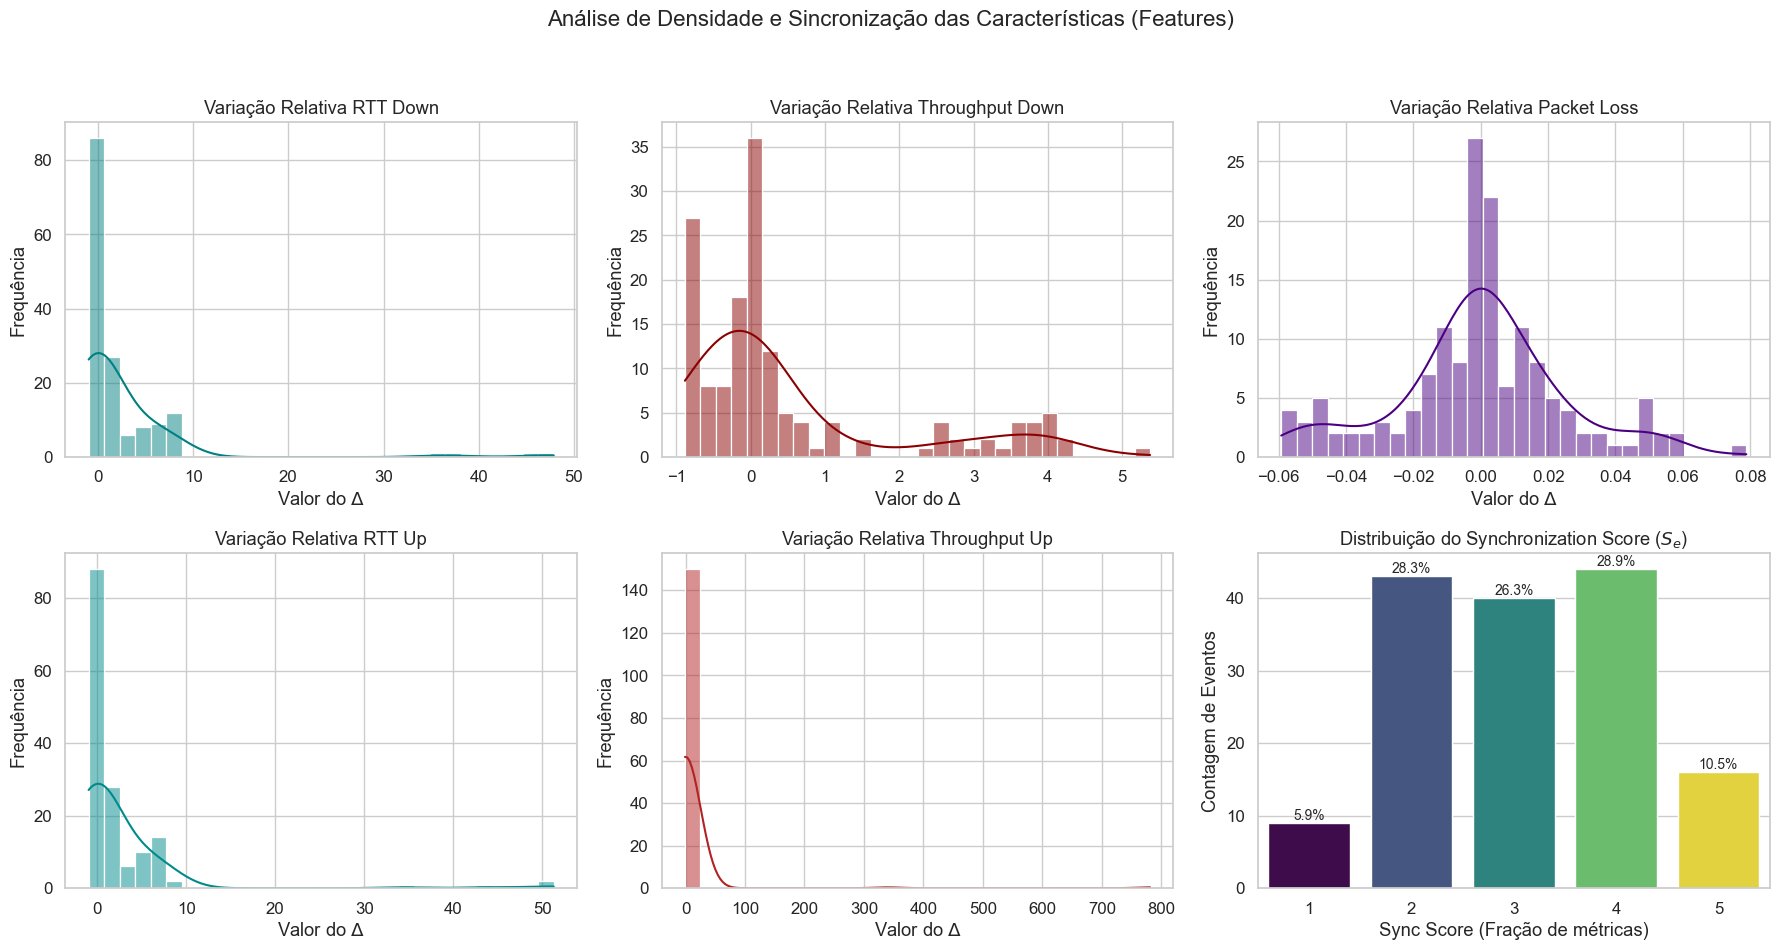

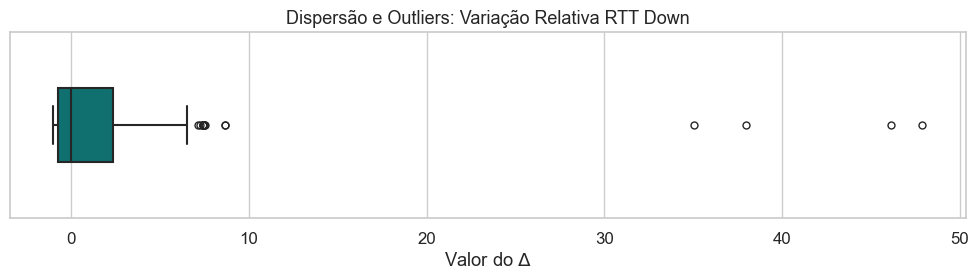

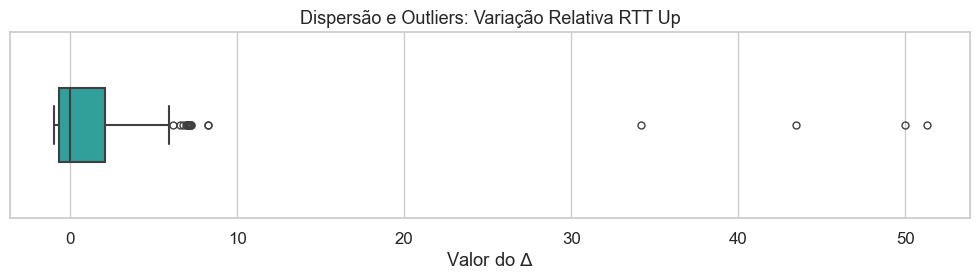

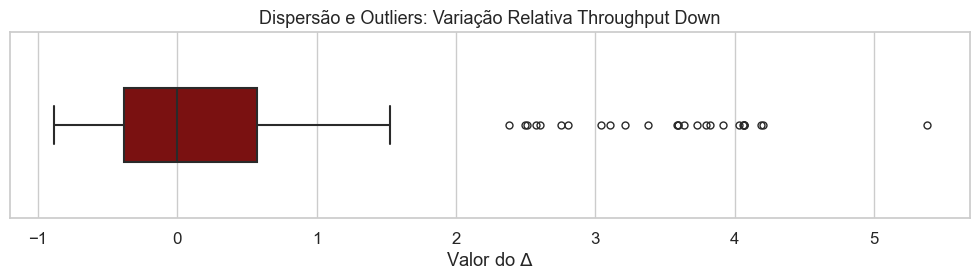

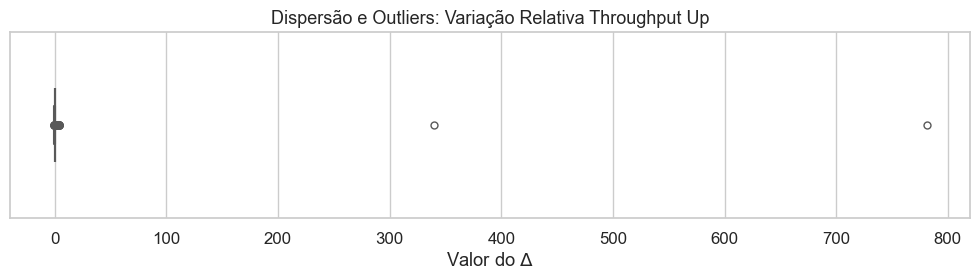

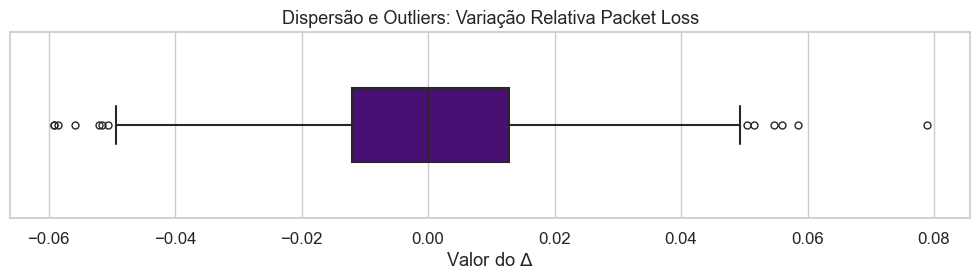

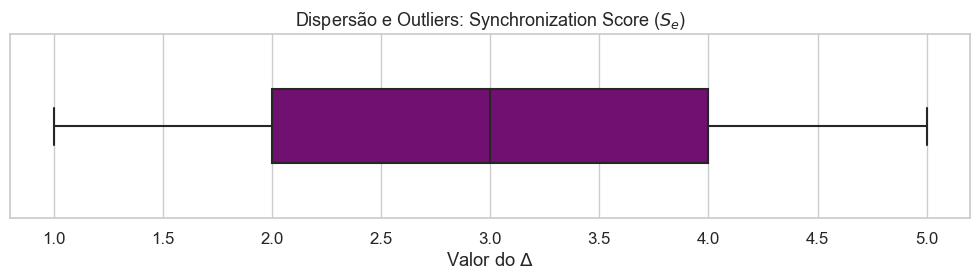

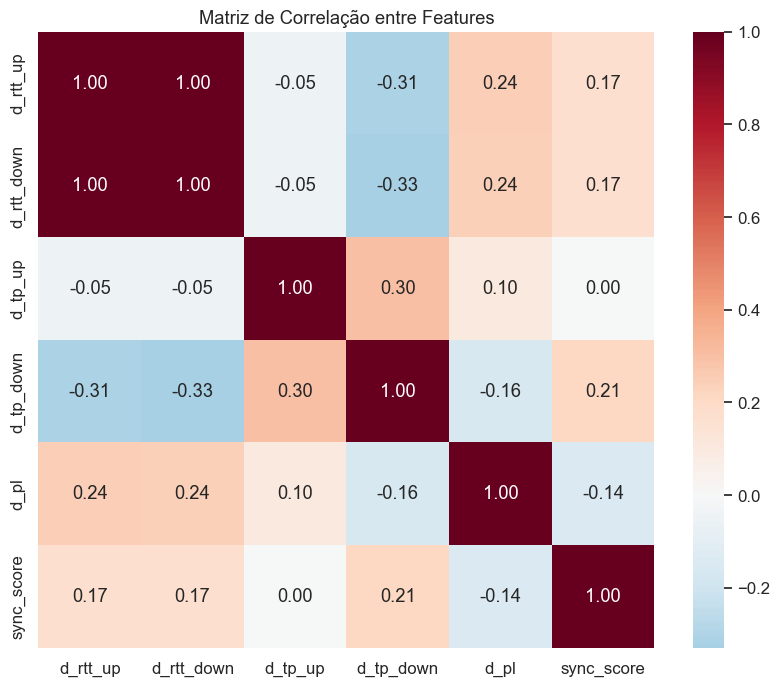

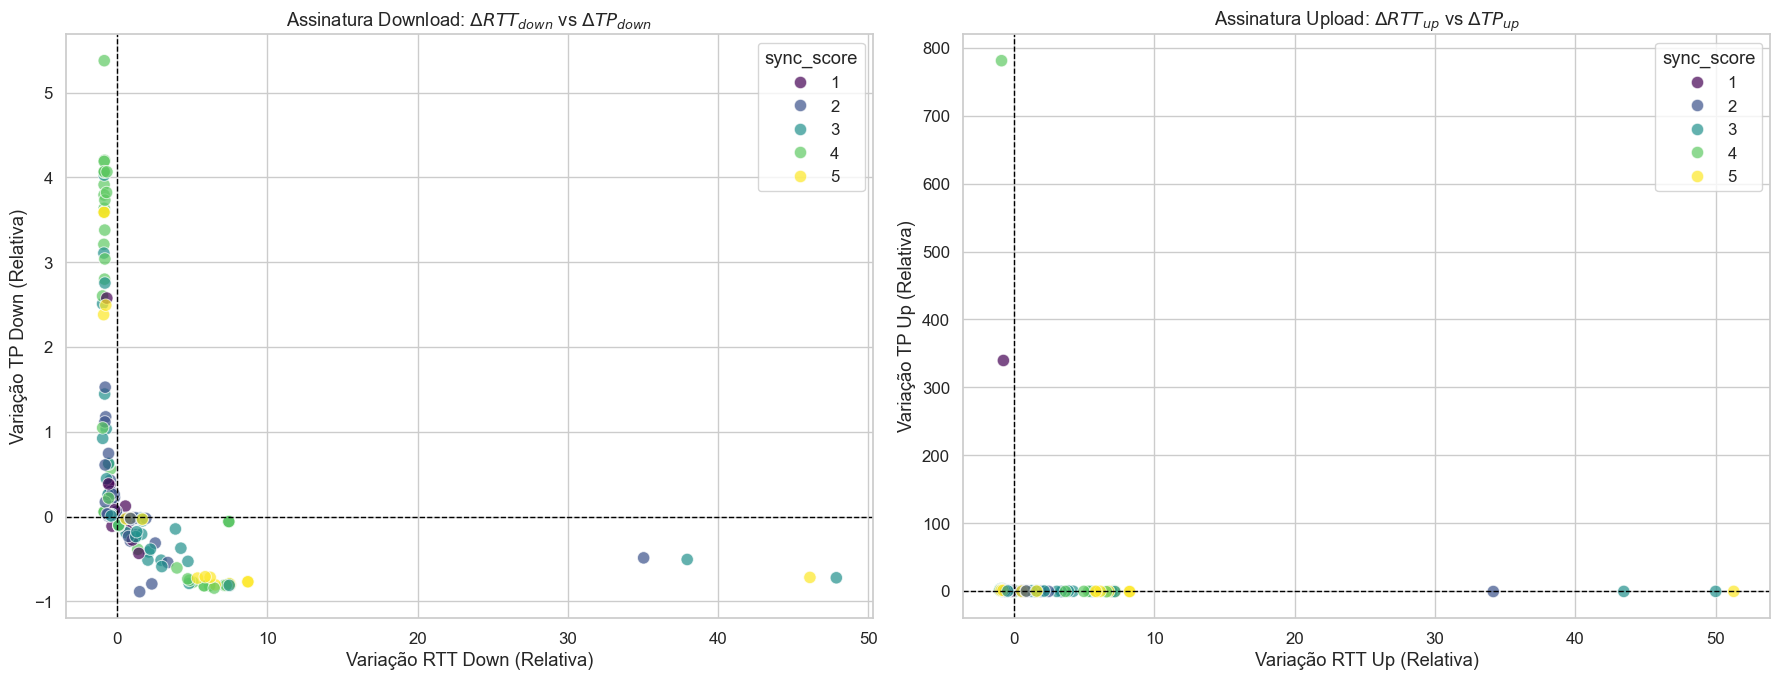

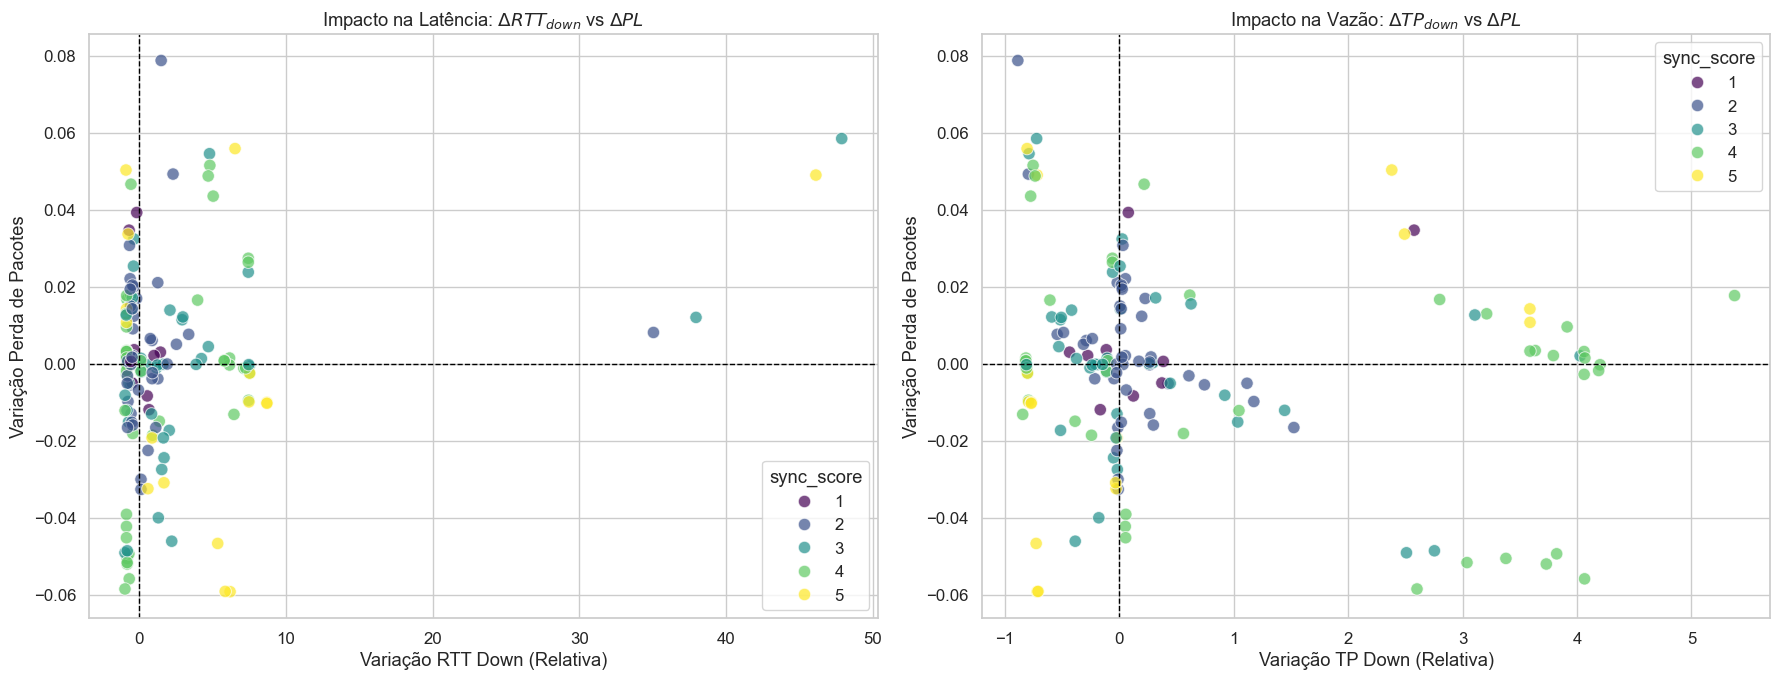

In [3]:
# Filtro de corte
df_filtrado = df[
    ((df['d_rtt_down_abs'] > 0) & (df['d_rtt_down_abs'] >= corte)) |
    ((df['d_rtt_down_abs'] < 0) & (df['d_rtt_down_abs'] <= -corte))|
    ((df['d_rtt_up_abs'] > 0) & (df['d_rtt_up_abs'] >= corte)) |
    ((df['d_rtt_up_abs'] < 0) & (df['d_rtt_up_abs'] <= -corte))     
]

if outlier_cut:
    # Selecionar apenas colunas numéricas
    feature_cols = ['d_rtt_down', 'd_tp_down', 'd_rtt_up', 'd_tp_up', 'd_pl']
    
    # Calcular limites apenas para as features do modelo
    low = float('-inf') #df_filtrado[feature_cols].quantile(0.01)
    high = float('inf') # df_filtrado[feature_cols].quantile(0.95)

    # Filtrar o DataFrame removendo linhas que possuam outliers em qualquer coluna numérica
    df_filtrado= df_filtrado[((df_filtrado[feature_cols] >= low) & (df_filtrado[feature_cols] <= high)).all(axis=1)]

EDA(df_filtrado)

# Clusterização

In [4]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# 1. Preparação dos dados
feature_cols = ['d_rtt_down', 'd_tp_down', 'd_rtt_up', 'd_tp_up', 'd_pl', 'sync_score']
X = df_filtrado[feature_cols].values
X_scaled = StandardScaler().fit_transform(X)

# 2. Loop para diferentes valores de K
results = []
range_k = range(2, 11)

for k in range_k:
    # ADICIONADO: covariance_type='full' para alinhar com o segundo código
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42).fit(X_scaled)
    
    # AJUSTADO: score(X) * len(X) para obter o LL Total em vez da média (lower_bound_)
    ll_total = gmm.score(X_scaled) * len(X_scaled)
    
    results.append({
        'k': k,
        'll': ll_total,
        'aic': gmm.aic(X_scaled), # Adicionado AIC
        'bic': gmm.bic(X_scaled)
    })

# 3. Criar tabela de métricas e calcular variações
df_metrics = pd.DataFrame(results)
df_metrics['d_ll'] = df_metrics['ll'].diff().fillna(0)
df_metrics['d_aic'] = df_metrics['aic'].diff().fillna(0)
df_metrics['d_bic'] = df_metrics['bic'].diff().fillna(0)

print("Tabela de Métricas (Model Selection):")
# Formatação para facilitar a leitura comparativa
print(df_metrics[['k', 'll', 'aic', 'bic', 'd_ll', 'd_aic', 'd_bic']].round(2))
print("-" * 30)

# 4. Encontrar o K ideal
# Para ser consistente com o segundo código, o ideal é olhar o BIC (mínimo valor)
best_k_bic = df_metrics.loc[df_metrics['bic'].idxmin(), 'k']
print(f"Melhor K identificado (pelo menor BIC): {best_k_bic}\n")

Tabela de Métricas (Model Selection):
    k       ll      aic      bic     d_ll    d_aic    d_bic
0   2  -677.25  1464.50  1630.81     0.00     0.00     0.00
1   3   502.31  -838.62  -587.64  1179.56 -2303.12 -2218.45
2   4   571.98  -921.97  -586.32    69.67   -83.35     1.32
3   5   721.90 -1165.80  -745.48   149.92  -243.83  -159.17
4   6   813.46 -1292.92  -787.93    91.56  -127.12   -42.45
5   7   909.45 -1428.90  -839.25    95.99  -135.98   -51.31
6   8   990.28 -1534.56  -860.24    80.83  -105.66   -20.99
7   9  1099.47 -1696.95  -937.95   109.19  -162.38   -77.71
8  10  1204.56 -1851.11 -1007.45   105.08  -154.17   -69.50
------------------------------
Melhor K identificado (pelo menor BIC): 10



In [9]:
K = best_k_bic
K = 6
# 5. Executar o modelo final para o melhor K
gmm_final = GaussianMixture(n_components=int(K), covariance_type='full', random_state=42)
labels = gmm_final.fit_predict(X_scaled)
df_filtrado['cluster'] = labels
if df_filtrado['sync_score'].dtype.kind != 'i':
    df_filtrado['sync_score'] = (df_filtrado['sync_score'] * 5).astype(int)

# 6. Tabela com médias (mantendo a lógica do primeiro código)
cluster_stats = df_filtrado.groupby('cluster').agg(
    count=('cluster', 'size')
).join(df_filtrado.groupby('cluster')[feature_cols].mean())

# Printar com 3 casas decimais para facilitar a leitura
cluster_stats = cluster_stats.round(3)

# ordenar as colunas por rtt, tp e pl para facilitar a comparação entre clusters
cols_order = ['count', 'd_rtt_down', 'd_rtt_up', 'd_tp_down', 'd_tp_up', 'd_pl', 'sync_score']
cluster_stats = cluster_stats[cols_order]
print("Estatísticas por Cluster (Melhor K):")
print(cluster_stats)

Estatísticas por Cluster (Melhor K):
         count  d_rtt_down  d_rtt_up  d_tp_down  d_tp_up   d_pl  sync_score
cluster                                                                    
0            9      -0.213    -0.347      1.147   38.887 -0.004       2.556
1            4      41.748    44.723     -0.608   -0.595  0.032       3.250
2           99       1.590     1.541     -0.132   -0.147 -0.004       2.889
3            1      -0.866    -0.868      5.377  781.147  0.018       4.000
4           15       3.821     3.735     -0.291   -0.244  0.038       3.333
5           24      -0.855    -0.856      3.510    2.364 -0.012       3.958


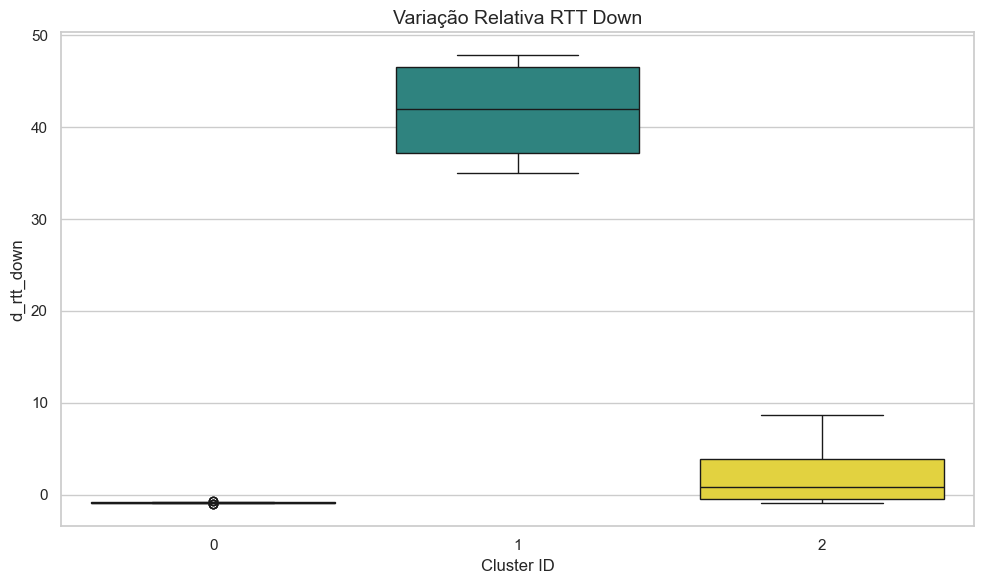

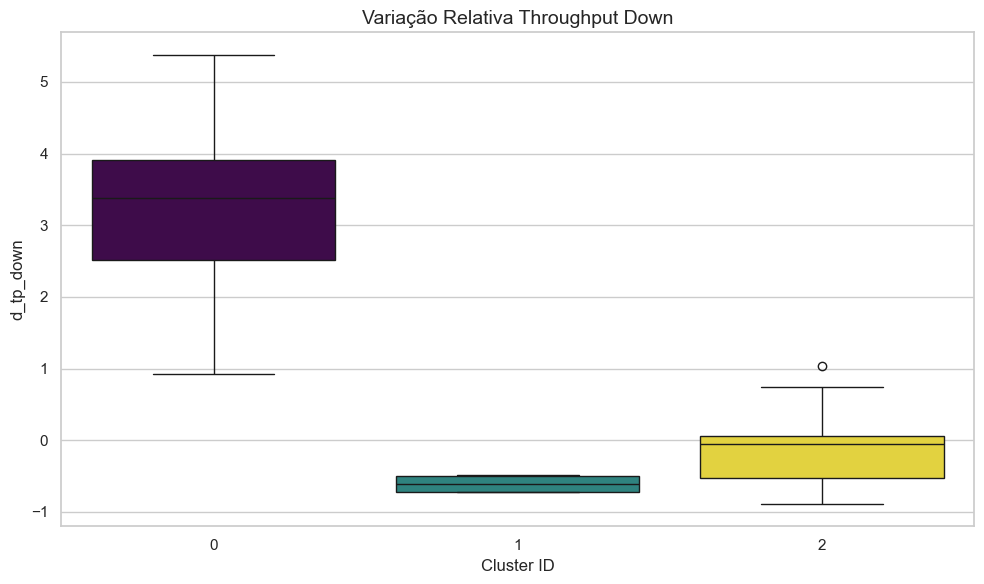

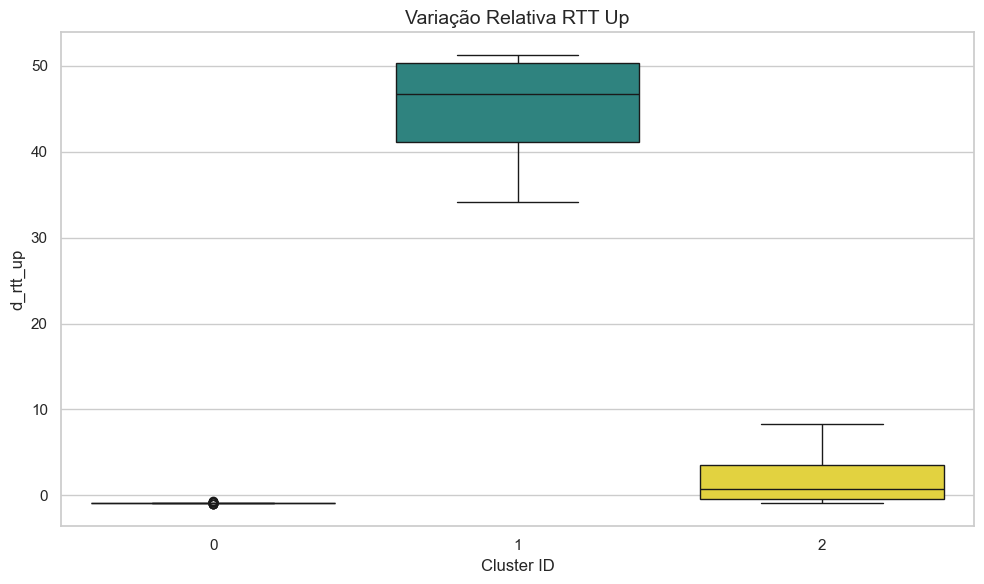

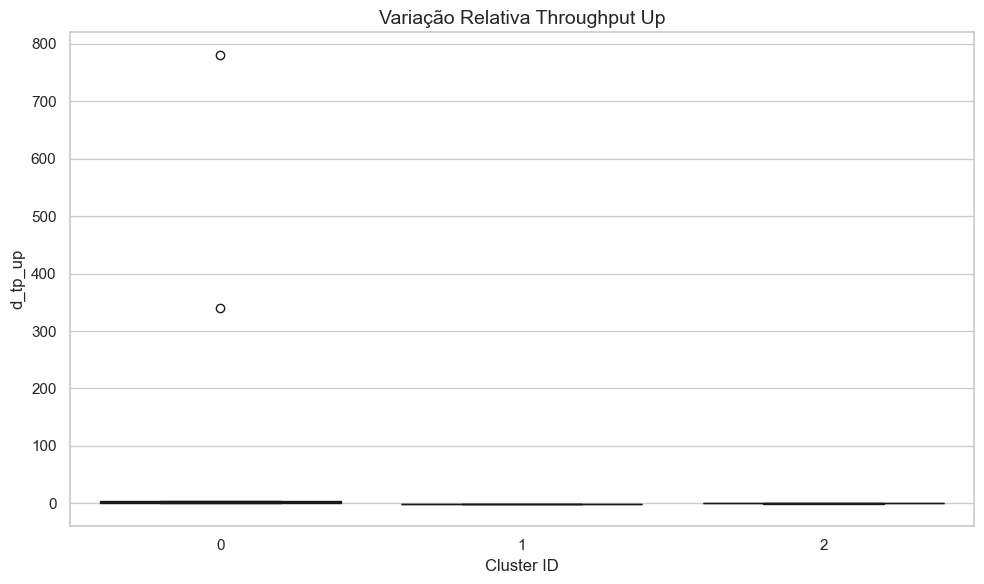

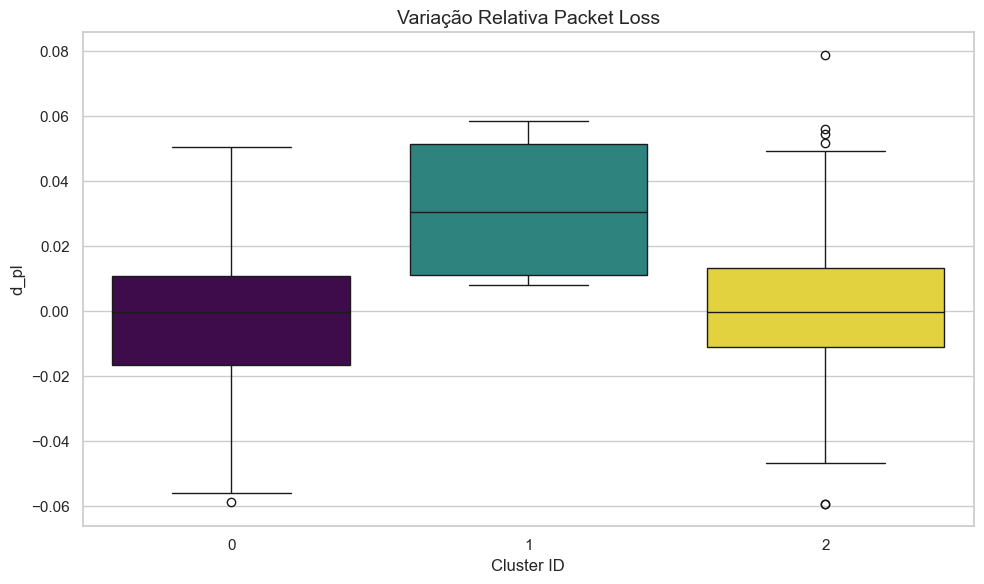

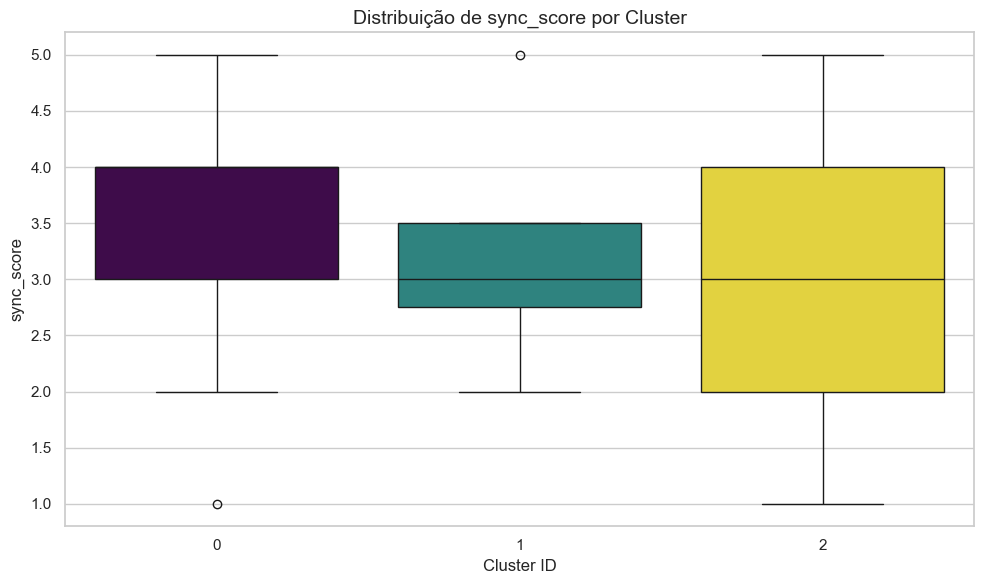

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração estética dos gráficos
sns.set_theme(style="whitegrid")

# MApeamento das métricas para títulos e cores
metric_info = {
    'd_rtt_down': (f'Variação {relativa_absoluta} RTT Down', 'teal'),
    'd_tp_down': ('Variação Relativa Throughput Down', 'darkred'),
    'd_pl': ('Variação Relativa Packet Loss', 'indigo'),
    'd_rtt_up': (f'Variação {relativa_absoluta} RTT Up', 'darkcyan'),
    'd_tp_up': ('Variação Relativa Throughput Up', 'firebrick')
}

# Iterar sobre cada métrica para criar uma figura individual
for col in feature_cols:
    plt.figure(figsize=(10, 6))
    
    # Criar o boxplot: X é o cluster, Y é a métrica atual
    sns.boxplot(x='cluster', y=col, data=df_filtrado, palette='viridis', hue='cluster', legend=False)
    
    # Adicionar pontos (stripplot) para ver a distribuição real dos dados sobre o boxplot
    # sns.stripplot(x='cluster', y=col, data=df_filtrado, color='black', alpha=0.3, jitter=True)
    
    title, color = metric_info.get(col, (f'Distribuição de {col} por Cluster', 'blue'))
    plt.title(title, fontsize=14)
    plt.xlabel('Cluster ID', fontsize=12)
    plt.ylabel(col, fontsize=12)
    
    plt.tight_layout()
    plt.show()